# ================================================================
# Complete TUAR Artifact Denoising Project Using a Residual GAN
# Paired Data: Noisy input = clean signal + synthetic artifact noise
# The generator learns to predict the artifact residual so that:
#  clean_predicted = noisy_input - predicted_residual
# ================================================================

In [1]:
import os
import numpy as np
import pandas as pd
import mne
from mne import pick_types
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import welch
import scipy.stats as st  # For computing confidence intervals

# 1) Imports & Parameters

In [3]:
# Define Kaggle input directories (adjust these paths as needed)
BASE_DIR = Path("/kaggle/input/eeg-tuar")      # root of your upload
EDF_DIR  = BASE_DIR / "edf"                    # contains 01_tcp_ar, etc.
DOCS_DIR = BASE_DIR / "DOCS"                   # contains montage .txt files

# Data and training parameters
SEG_LEN = 1000               # Length of each EEG segment (e.g., 4 s @ 250 Hz)
EPOCHS = 20
BATCH_SIZE = 32 #16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) TUAR Data Loading & Segmentation

In [4]:
# Standardize channel names (convert to uppercase, remove extra parts)
def standardize_channel(ch):
    return ch.replace("EEG ", "").replace("-REF", "").replace("-LE", "").strip().upper()

def load_edf_csv_pair(edf_file):
    edf_path = Path(edf_file)
    
    # 1) Load raw EEG using MNE
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
    eeg_picks = pick_types(raw.info, eeg=True, meg=False, stim=False)
    raw.pick(picks=eeg_picks)
    sfreq = raw.info["sfreq"]
    
    # 2) Get the referential channel names and standardize them
    ref_chs = raw.ch_names
    ref_chs_std = [standardize_channel(ch) for ch in ref_chs]
    data_ref = raw.get_data()   # shape: (n_ref, n_times)
    n_times = data_ref.shape[1]
    
    # 3) Read the montage file to build bipolar mapping.
    #    The montage file is expected to be named like: "01_tcp_ar_montage.txt"
    mont_name = edf_path.parent.name  # e.g., "01_tcp_ar"
    mont_file = DOCS_DIR / f"{mont_name}_montage.txt"
    if not mont_file.exists():
        raise FileNotFoundError(f"Montage file {mont_file} not found.")
    
    bip_map = {}
    with open(mont_file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("montage"):
                # Example line:
                # montage = 0, FP1-F7: EEG FP1-REF -- EEG F7-REF
                parts = line.split(",")
                if len(parts) < 2:
                    continue
                mapping_str = parts[1].strip()
                try:
                    label, electrodes = mapping_str.split(":", 1)
                except ValueError:
                    continue  # Skip malformed lines
                label = label.strip()  # e.g., "FP1-F7"
                electrodes = electrodes.strip()
                if "--" in electrodes:
                    elec_pair = electrodes.split("--")
                    if len(elec_pair) == 2:
                        elec1 = standardize_channel(elec_pair[0])
                        elec2 = standardize_channel(elec_pair[1])
                        bip_map[label] = (elec1, elec2)
    
    # 4) Build bipolar signals using the montage mapping.
    bip_chs = []  # list of bipolar channel names (from montage file)
    bip_data = [] # list of corresponding bipolar signals
    for lab, (elec1, elec2) in bip_map.items():
        if elec1 in ref_chs_std and elec2 in ref_chs_std:
            idx1 = ref_chs_std.index(elec1)
            idx2 = ref_chs_std.index(elec2)
            bip_data.append(data_ref[idx1] - data_ref[idx2])
            bip_chs.append(lab)
    if len(bip_data) == 0:
        raise ValueError(f"No bipolar channels created for EDF: {edf_path}. Check your montage mapping.")
    bipolar_data = np.vstack(bip_data)  # shape: (n_bip, n_times)
    
    # 5) Load CSV annotations and create an artifact mask for the bipolar channels.
    # The CSV contains annotations on bipolar channels (matching names in bip_chs).
    csv_path = edf_path.with_suffix(".csv")
    ann = pd.read_csv(csv_path, comment="#")
    ann["channel_std"] = ann["channel"].apply(lambda x: standardize_channel(str(x)))
    mask = np.zeros((len(bip_chs), n_times), dtype=bool)
    for _, row in ann.iterrows():
        ch = row["channel_std"]
        if ch in bip_chs:
            idx = bip_chs.index(ch)
            s = int(row.start_time * sfreq)
            e = int(row.stop_time * sfreq)
            s = max(0, min(s, n_times - 1))
            e = max(0, min(e, n_times - 1))
            mask[idx, s:e] = True
            
    return bipolar_data, ann, bip_chs, mask, sfreq

# ---------------------------
# 3) Segmenting TUAR Data
# ---------------------------
# Collect all EDF files recursively from EDF_DIR.
edf_files = list(EDF_DIR.rglob("*.edf"))
if not edf_files:
    raise RuntimeError(f"No EDF files found under {EDF_DIR}")
print(f"Found {len(edf_files)} EDF files.")

# Now, segment each EDF recording into windows using the bipolar data.
clean_segments = []
artifact_segments = []

for edf in edf_files[:150]:
    try:
        bipolar_data, ann, bip_chs, mask, sfreq = load_edf_csv_pair(edf)
    except Exception as e:
        print(f"Skipping {edf} due to error: {e}")
        continue
    n_times = bipolar_data.shape[1]
    
    # Scale data. TUAR signals are in Volts; scale to microvolt-level.
    bipolar_data = bipolar_data * 1e4  # adjust scaling as needed
    
    # For each bipolar channel, segment into non-overlapping windows.
    # Each window is shaped [1, SEG_LEN].
    for ch_idx in range(len(bip_chs)):
        sig = bipolar_data[ch_idx]  # shape: (n_times,)
        m = mask[ch_idx]
        for i in range(0, n_times - SEG_LEN, SEG_LEN):
            window = sig[i:i+SEG_LEN][None]  # shape: [1, SEG_LEN]
            # Mark as artifact if any sample in the window is flagged.
            if m[i:i+SEG_LEN].any():
                artifact_segments.append(window)
            else:
                clean_segments.append(window*10)

print(f"Segmentation complete. Clean windows: {len(clean_segments)}, Artifact windows: {len(artifact_segments)}")

Found 310 EDF files.
Segmentation complete. Clean windows: 797104, Artifact windows: 241512


# 3) Create Paired Data for Supervised Learning (Optional)

In [9]:
# Since TUAR does not inherently provide paired examples, we can synthesize pairs.
# Here we use clean segments and add synthetic artifact noise.
def create_paired_artifact(clean_segs, noise_scale=0.3):
    paired_artifacts = []
    for seg in clean_segs:
        noisy_seg = seg + noise_scale * np.random.randn(*seg.shape)
        paired_artifacts.append(noisy_seg)
    return paired_artifacts
    
clean_segments=clean_segments[:90000]
paired_artifact_segments = create_paired_artifact(clean_segments, noise_scale=0.3)

# 4) Dataset & DataLoader

In [10]:
class EEGDataset(Dataset):
    def __init__(self, clean_segs, artifact_segs):
        assert len(clean_segs) == len(artifact_segs), "Mismatch: paired data must be equal."
        self.clean = clean_segs
        self.artifact = artifact_segs

    def __len__(self):
        return len(self.clean)

    def __getitem__(self, idx):
        # Each segment shape: [1, SEG_LEN]. Convert to tensors.
        clean_tensor = torch.tensor(self.clean[idx]).float()
        artifact_tensor = torch.tensor(self.artifact[idx]).float()
        return artifact_tensor, clean_tensor  # (noisy input, clean target)

# Split clean and paired artifact data into training (80%) and test (20%)
clean_train, clean_test, artifact_train, artifact_test = train_test_split(
    clean_segments, paired_artifact_segments, test_size=0.2, random_state=42
)

# Create training and test datasets
train_dataset = EEGDataset(clean_train, artifact_train)
test_dataset = EEGDataset(clean_test, artifact_test)

# Use DataLoader for training and testing
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)  # Evaluate one sample at a time

In [11]:
# Print a few clean-artifact pairs from test_loader
num_samples_to_print = 5  # Adjust how many pairs you want to print

print("=== Sample Clean and Artifact Signal Pairs ===")
for idx, (artifact_input, clean_input) in enumerate(test_loader):
    artifact_np = artifact_input.cpu().numpy()[0, 0]  # Extract first channel from batch
    clean_np = clean_input.cpu().numpy()[0, 0]

    print(f"Sample {idx+1}:")
    print("Artifact Signal (first 10 values):", artifact_np[:10])
    print("Clean Signal (first 10 values):   ", clean_np[:10])
    print("------------------------------------------------------")

    if idx + 1 >= num_samples_to_print:  # Stop after printing desired samples
        break

=== Sample Clean and Artifact Signal Pairs ===
Sample 1:
Artifact Signal (first 10 values): [ 1.9800439   1.4398013   0.3523032   0.21219346  1.1877799  -0.01646963
 -0.5939432  -0.56356096 -0.23921058  0.6944003 ]
Clean Signal (first 10 values):    [ 1.8157945   1.4648426   0.3356931   0.76293886  1.0528556   0.22888166
 -0.5035396  -0.70190376 -0.10681144 -0.07629389]
------------------------------------------------------
Sample 2:
Artifact Signal (first 10 values): [0.7693866 1.9817641 1.8793373 1.312331  1.5568736 1.5164412 2.1082785
 1.5239768 0.643481  2.4066617]
Clean Signal (first 10 values):    [1.1544468  1.9240781  1.6898425  0.97040457 1.1879091  2.1248515
 2.342356   1.5225314  1.2548336  2.1081202 ]
------------------------------------------------------
Sample 3:
Artifact Signal (first 10 values): [ 0.4129817  -0.14736813  0.03116473  1.5519289   1.2398458   0.13073649
  0.23606347  1.3334507   1.1693531  -0.99480075]
Clean Signal (first 10 values):    [ 0.80309343 -0.033

# 5) Model Definitions

In [12]:
# 5a) Residual Generator:
#    The generator takes the noisy (artifact) input and predicts its residual.
class ResidualGenerator(nn.Module):
    def __init__(self):
        super(ResidualGenerator, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=2, batch_first=True)
        self.fc   = nn.Linear(50, 1)
    
    def forward(self, x):
        # Input x: (batch, 1, SEG_LEN)
        x = x.permute(0, 2, 1)  # (batch, SEG_LEN, 1)
        lstm_out, _ = self.lstm(x)
        residual = torch.tanh(self.fc(lstm_out))
        residual = residual.permute(0, 2, 1)  # (batch, 1, SEG_LEN)
        return residual

# 5b) Discriminator:
#    A CNN that distinguishes between real clean signals and the generator’s denoised outputs.
def calc_final_length_exact(seq_len):
    L = seq_len
    for i in range(4):
        L_conv = ((L - 1) // 2) + 1
        L = L_conv // 2
    return L

final_len = calc_final_length_exact(SEG_LEN)
    
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        def block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=7, stride=2, padding=3),
                nn.LeakyReLU(0.2),
                nn.MaxPool1d(2)
            )
        self.net = nn.Sequential(
            block(1, 16),
            block(16, 32),
            block(32, 64),
            block(64, 64),
            nn.Flatten(),
            nn.Linear(64 * final_len, 1)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate models and optimizers
G = ResidualGenerator().to(device)
D = Discriminator().to(device)
optG = optim.Adam(G.parameters(), lr=5e-4) # Nan after epoch 5
optD = optim.Adam(D.parameters(), lr=5e-5)
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()
lam = 0.01  # weight for adversarial loss

# 6) Training Loop (Residual Learning)

Epoch 1: 100%|██████████| 2250/2250 [00:43<00:00, 52.31it/s]


Epoch 1: D-loss = 1.3769, G-loss = 0.0631


/tmp/ipykernel_31/3521053170.py:64: RuntimeWarning: divide by zero encountered in log10
  snr_val = 10 * np.log10(np.mean(clean_np[0,0]**2) / (np.mean((clean_np[0,0] - denoised_np[0,0])**2) + eps))


Epoch 1: Avg SNR = -inf dB
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


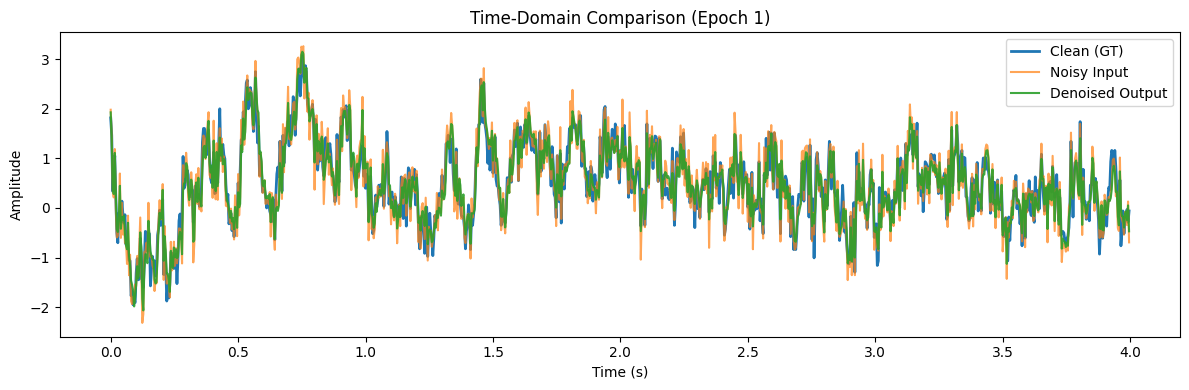

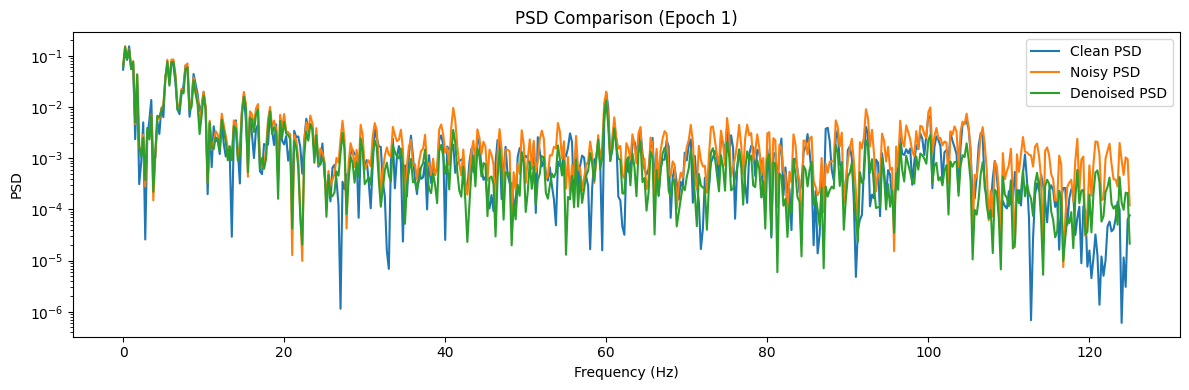

Epoch 2: 100%|██████████| 2250/2250 [00:42<00:00, 53.55it/s]


Epoch 2: D-loss = 1.3304, G-loss = 0.0550
Epoch 2: Avg SNR = -inf dB
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


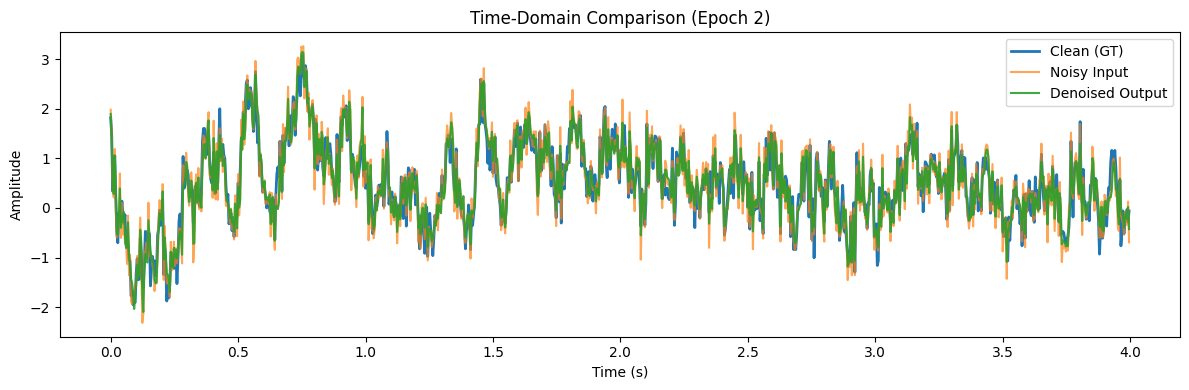

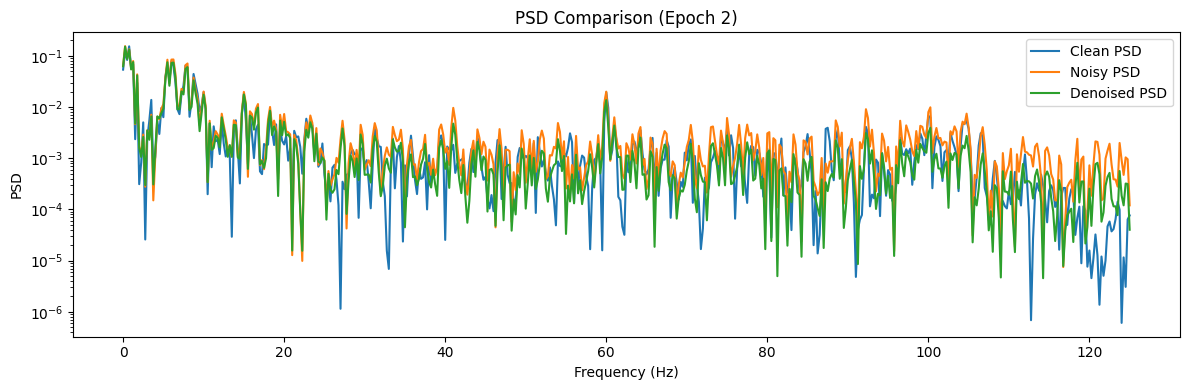

Epoch 3: 100%|██████████| 2250/2250 [00:42<00:00, 53.40it/s]


Epoch 3: D-loss = 1.3136, G-loss = 0.0541
Epoch 3: Avg SNR = -inf dB
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


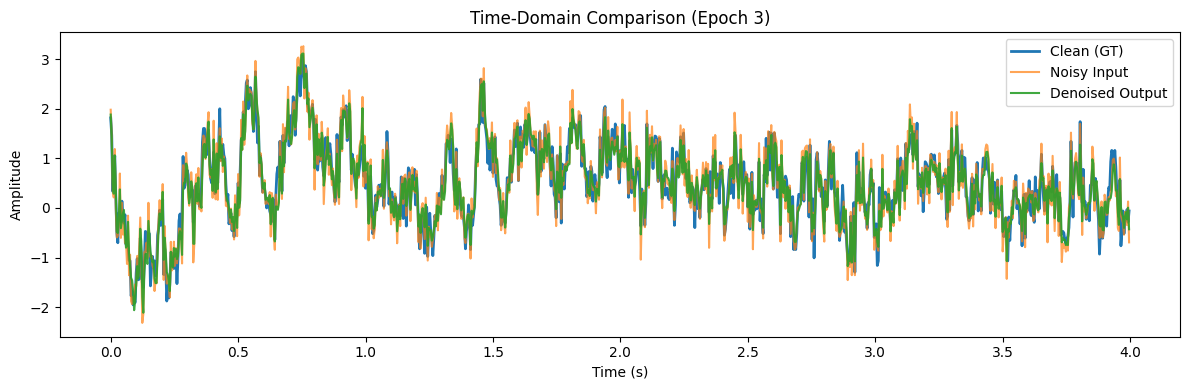

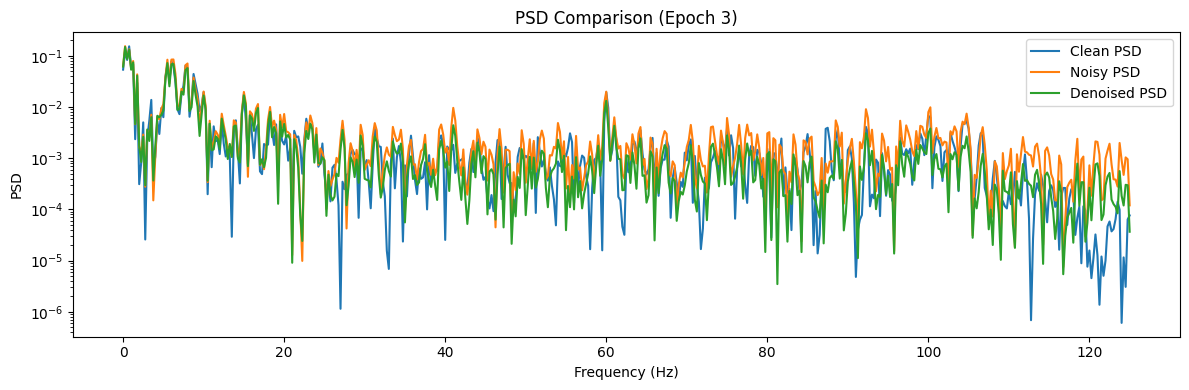

Epoch 4: 100%|██████████| 2250/2250 [00:42<00:00, 53.54it/s]


Epoch 4: D-loss = 1.3106, G-loss = 0.0538
Epoch 4: Avg SNR = -inf dB
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


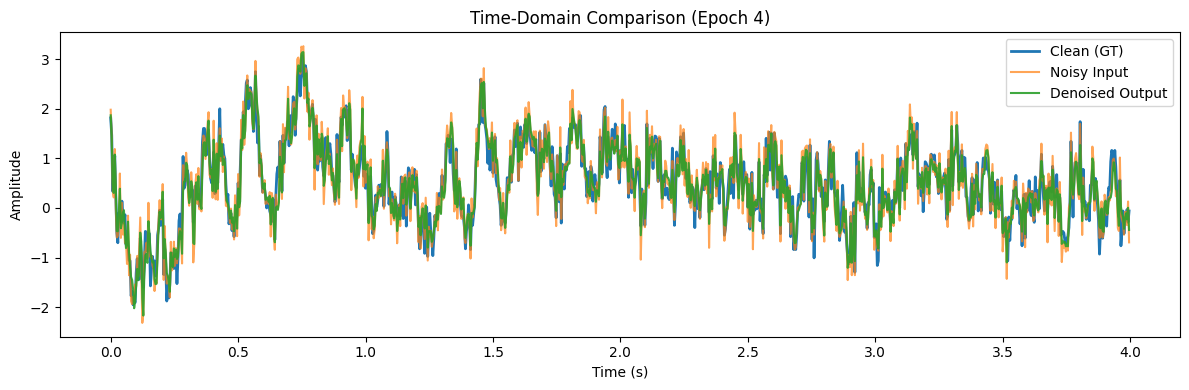

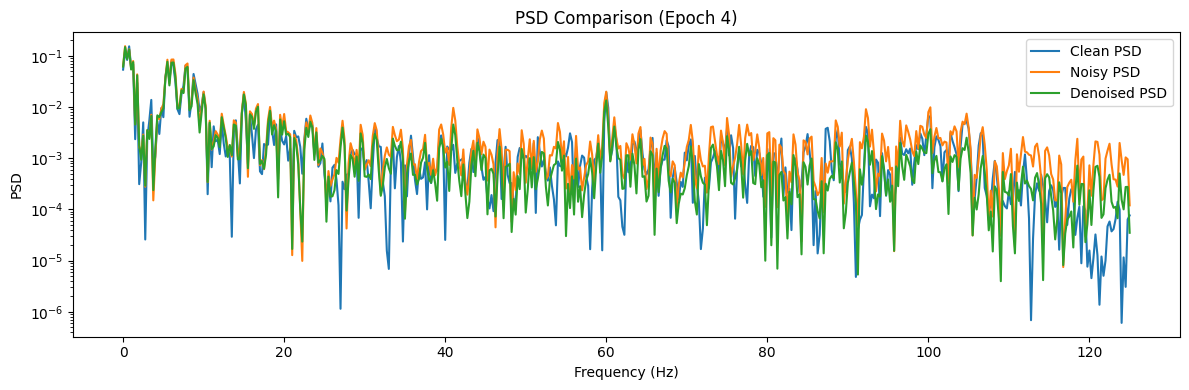

Epoch 5: 100%|██████████| 2250/2250 [00:41<00:00, 53.62it/s]


Epoch 5: D-loss = 1.3082, G-loss = 0.0537
Epoch 5: Avg SNR = -inf dB
✅ Best model updated (lower G-loss)! Saved at /kaggle/working/checkpoint_epoch_best.pth


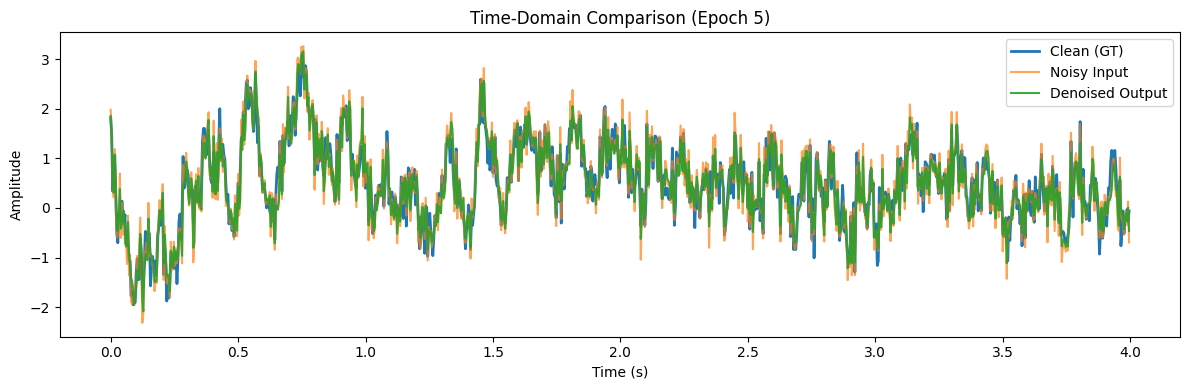

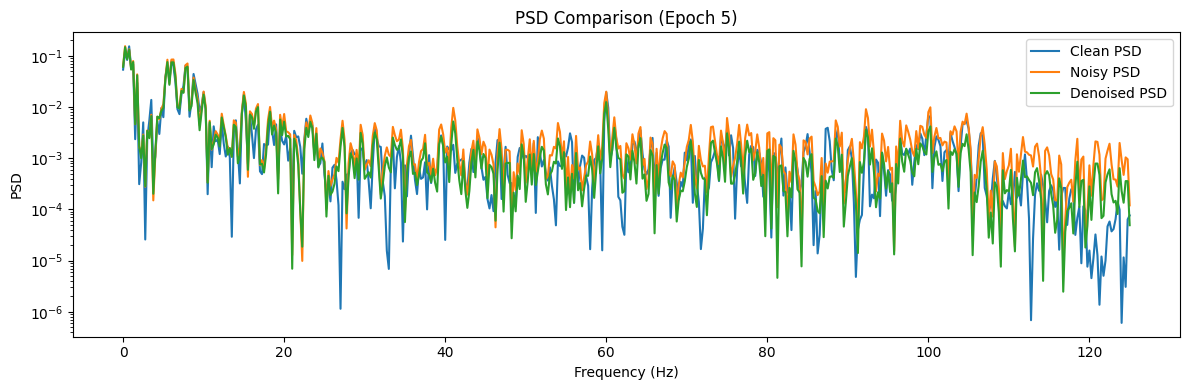

In [13]:
# Directory to save epoch checkpoints and plots
checkpoint_dir = "/kaggle/working"
plot_dir = os.path.join(checkpoint_dir, "epoch_plots")
os.makedirs(plot_dir, exist_ok=True)

# Initialize best loss to a high value (since lower loss is better)
best_loss = float("inf")

for epoch in range(EPOCHS):
    total_lossD, total_lossG = 0.0, 0.0
    G.train()
    D.train()
    
    for artifact_input, clean_input in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        
        # --- Update Discriminator ---
        optD.zero_grad()
        real_logits = D(clean_input)
        predicted_residual = G(artifact_input)
        fake_clean = artifact_input - predicted_residual
        fake_logits = D(fake_clean.detach())

        # Apply label smoothing
        real_labels = torch.ones_like(real_logits) * 0.9
        fake_labels = torch.zeros_like(fake_logits) + 0.1

        lossD = bce_loss(real_logits, real_labels) + bce_loss(fake_logits, fake_labels)
        lossD.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
        optD.step()

        # --- Update Generator ---
        optG.zero_grad()
        predicted_residual = G(artifact_input)
        fake_clean = artifact_input - predicted_residual
        
        loss_recon = mse_loss(fake_clean, clean_input)
        loss_adv = bce_loss(D(fake_clean), real_labels)
        lossG = loss_recon + lam * loss_adv
        lossG.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        optG.step()

        total_lossD += lossD.item()
        total_lossG += lossG.item()
    
    avg_lossD = total_lossD / len(train_loader)
    avg_lossG = total_lossG / len(train_loader)
    print(f"Epoch {epoch+1}: D-loss = {avg_lossD:.4f}, G-loss = {avg_lossG:.4f}")

    # Evaluate (here we can also compute an average, but for saving the best checkpoint we focus on loss)
    G.eval()
    snr_scores = []
    for artifact_input, clean_input in test_loader:
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        with torch.no_grad():
            predicted_residual = G(artifact_input)
            denoised_tensor = artifact_input - predicted_residual
        clean_np = clean_input.cpu().numpy()
        denoised_np = denoised_tensor.cpu().numpy()
        eps = 1e-10
        # Compute SNR from the first sample only (for monitoring)
        snr_val = 10 * np.log10(np.mean(clean_np[0,0]**2) / (np.mean((clean_np[0,0] - denoised_np[0,0])**2) + eps))
        snr_scores.append(snr_val)
    avg_snr = np.mean(snr_scores)
    print(f"Epoch {epoch+1}: Avg SNR = {avg_snr:.2f} dB")

    # Save checkpoint for this epoch
    checkpoint = {
        'epoch': epoch + 1,
        'G_state_dict': G.state_dict(),
        'D_state_dict': D.state_dict(),
        'optG_state_dict': optG.state_dict(),
        'optD_state_dict': optD.state_dict(),
        'lossD': avg_lossD,
        'lossG': avg_lossG,
        'snr': avg_snr
    }
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    torch.save(checkpoint, checkpoint_path)
    
    # Save best checkpoint based on least generator loss (avg_lossG)
    if avg_lossG < best_loss:
        best_loss = avg_lossG
        best_checkpoint_path = os.path.join(checkpoint_dir, "checkpoint_epoch_best.pth")
        torch.save(checkpoint, best_checkpoint_path)
        print(f"✅ Best model updated (lower G-loss)! Saved at {best_checkpoint_path}")

    # --- Plotting for this Epoch ---
    # Extract one sample from test_loader for visualization
    for artifact_input, clean_input in test_loader:
        artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
        with torch.no_grad():
            predicted_residual = G(artifact_input)
            denoised_tensor = artifact_input - predicted_residual
        sample_artifact_signal = artifact_input.cpu().numpy()[0,0]
        sample_clean_signal = clean_input.cpu().numpy()[0,0]
        denoised_signal = denoised_tensor.cpu().numpy()[0,0]
        break

    fs = 250.0  # Sampling frequency in Hz
    times = np.arange(SEG_LEN) / fs

    # Time-domain plot
    plt.figure(figsize=(12, 4))
    plt.plot(times, sample_clean_signal, label="Clean (GT)", linewidth=2)
    plt.plot(times, sample_artifact_signal, label="Noisy Input", alpha=0.7)
    plt.plot(times, denoised_signal, label="Denoised Output", alpha=0.9)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time-Domain Comparison (Epoch {epoch+1})")
    plt.legend()
    plt.tight_layout()
    plot_filename_td = os.path.join(plot_dir, f"epoch_{epoch+1}_time.png")
    plt.savefig(plot_filename_td)
    plt.show()

    # PSD plot using Welch's method
    f_clean, P_clean = welch(sample_clean_signal, fs=fs, nperseg=SEG_LEN)
    f_artifact, P_artifact = welch(sample_artifact_signal, fs=fs, nperseg=SEG_LEN)
    f_denoised, P_denoised = welch(denoised_signal, fs=fs, nperseg=SEG_LEN)

    plt.figure(figsize=(12, 4))
    plt.semilogy(f_clean, P_clean, label="Clean PSD")
    plt.semilogy(f_artifact, P_artifact, label="Noisy PSD")
    plt.semilogy(f_denoised, P_denoised, label="Denoised PSD")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(f"PSD Comparison (Epoch {epoch+1})")
    plt.legend()
    plt.tight_layout()
    plot_filename_psd = os.path.join(plot_dir, f"epoch_{epoch+1}_psd.png")
    plt.savefig(plot_filename_psd)
    plt.show()

# 7) Evaluation & Inference

In [ ]:
# Specify the checkpoint path (modify accordingly)
best_checkpoint_path = '/kaggle/working/checkpoint_epoch_best.pth'  # or use the best epoch filename

# Load the checkpoint dictionary
checkpoint = torch.load(best_checkpoint_path, map_location=device)

# Load the model state (for inference, we only need the generator)
G.load_state_dict(checkpoint['G_state_dict'])
G.eval()  # set the generator to evaluation mode

# If desired, you can also load the discriminator for evaluation, although for inference typically only G is used.
# D.load_state_dict(checkpoint['D_state_dict'])
# D.eval()

# Initialize lists for metrics
snr_scores, rrmse_scores = [], []

# Diagnostic flag to run the quick check only on the first sample
diagnostic_done = False
eps = 1e-10  # small constant to avoid division by zero

for artifact_input, clean_input in test_loader:
    artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
    
    with torch.no_grad():
        predicted_residual = G(artifact_input)
        denoised_signal = artifact_input - predicted_residual
    
    # Convert tensors to numpy arrays (assumed shape: [batch, 1, SEG_LEN])
    clean_np    = clean_input.cpu().numpy()
    denoised_np = denoised_signal.cpu().numpy()
    
    # Diagnostic: Check a subset of the first test sample to understand potential zero SNR issues.
    if not diagnostic_done:
        subset_size = 100  # examine only the first 100 data points for speed
        clean_subset    = clean_np[0, 0][:subset_size]
        denoised_subset = denoised_np[0, 0][:subset_size]
    
        # Compute basic power statistics over the subset
        signal_power = np.mean(clean_subset ** 2)
        error_power  = np.mean((clean_subset - denoised_subset) ** 2)
        snr_ratio    = signal_power / (error_power + eps)
    
        print("===== Diagnostic for First Test Sample =====")
        print("Signal Power (mean(clean^2)):", signal_power)
        print("Error Power (mean((clean-denoised)^2)):", error_power)
        print("SNR Ratio:", snr_ratio)
        print("Computed SNR (dB):", 10 * np.log10(snr_ratio))
        print("=============================================")
        diagnostic_done = True
    
    # Compute SNR and RRMSE for this test sample using the full segment.
    snr_val  = 10 * np.log10(np.mean(clean_np[0, 0] ** 2) / (np.mean((clean_np[0, 0] - denoised_np[0, 0]) ** 2) + eps))
    rrmse_val = np.sqrt(np.mean((denoised_np[0, 0] - clean_np[0, 0]) ** 2) / np.mean(clean_np[0, 0] ** 2))
    
    snr_scores.append(snr_val)
    rrmse_scores.append(rrmse_val)

# Compute aggregated statistics over all test samples
avg_snr   = np.mean(snr_scores)
std_snr   = np.std(snr_scores)
avg_rrmse = np.mean(rrmse_scores)
std_rrmse = np.std(rrmse_scores)
n_samples = len(snr_scores)

# Compute 95% confidence intervals using the t-distribution
ci_snr   = st.t.interval(0.95, n_samples - 1, loc=avg_snr, scale=(std_snr/np.sqrt(n_samples)))
ci_rrmse = st.t.interval(0.95, n_samples - 1, loc=avg_rrmse, scale=(std_rrmse/np.sqrt(n_samples)))

# Final aggregated metrics
print(f"✅ Final Evaluation Metrics:")
print(f"Avg SNR: {avg_snr:.2f} dB, Std: {std_snr:.2f}, 95% CI: {ci_snr}")
print(f"Avg RRMSE: {avg_rrmse:.4f}, Std: {std_rrmse:.4f}, 95% CI: {ci_rrmse}")

In [14]:
# # Specify the checkpoint path
# best_checkpoint_path = '/kaggle/working/checkpoint_epoch_best.pth'  # or use the best epoch filename

# # Load the checkpoint dictionary
# checkpoint = torch.load(best_checkpoint_path, map_location=device)

# # Load the model state (for inference, we only need the generator)
# G.load_state_dict(checkpoint['G_state_dict'])
# G.eval()  # set the generator to evaluation mode

# # If desired, you can also load the discriminator for evaluation, although for inference typically only G is used.
# # D.load_state_dict(checkpoint['D_state_dict'])
# # D.eval()

# # Initialize lists for metrics
# snr_scores, rrmse_scores = [], []

# # Diagnostic flag to run the quick check only on the first sample
# diagnostic_done = False
# eps = 1e-10  # small constant to avoid division by zero

# for artifact_input, clean_input in test_loader:
#     artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
    
#     with torch.no_grad():
#         predicted_residual = G(artifact_input)
#         denoised_signal = artifact_input - predicted_residual
    
#     # Convert tensors to numpy arrays (assumed shape: [batch, 1, SEG_LEN])
#     clean_np    = clean_input.cpu().numpy()
#     denoised_np = denoised_signal.cpu().numpy()
    
#     # Diagnostic: Check a subset of the first test sample to understand potential zero SNR issues.
#     if not diagnostic_done:
#         subset_size = 100  # examine only the first 100 data points for speed
#         clean_subset    = clean_np[0, 0][:subset_size]
#         denoised_subset = denoised_np[0, 0][:subset_size]
    
#         # Compute basic power statistics over the subset
#         signal_power = np.mean(clean_subset ** 2)
#         error_power  = np.mean((clean_subset - denoised_subset) ** 2)
#         snr_ratio    = signal_power / (error_power + eps)
    
#         print("===== Diagnostic for First Test Sample =====")
#         print("Signal Power (mean(clean^2)):", signal_power)
#         print("Error Power (mean((clean-denoised)^2)):", error_power)
#         print("SNR Ratio:", snr_ratio)
#         print("Computed SNR (dB):", 10 * np.log10(snr_ratio))
#         print("=============================================")
#         diagnostic_done = True
    
#     # Compute SNR and RRMSE for this test sample using the full segment.
#     # (Note: We add eps here to avoid a direct division by zero.)
#     snr_val  = 10 * np.log10(np.mean(clean_np[0,0] ** 2) / (np.mean((clean_np[0,0] - denoised_np[0,0]) ** 2) + eps))
#     rrmse_val = np.sqrt(np.mean((denoised_np[0,0] - clean_np[0,0]) ** 2) / np.mean(clean_np[0,0] ** 2))
    
#     snr_scores.append(snr_val)
#     rrmse_scores.append(rrmse_val)

# # Final averaged metrics across all test samples
# print(f"✅ Final Evaluation → Avg SNR: {np.mean(snr_scores):.2f} dB, Avg RRMSE: {np.mean(rrmse_scores):.4f}")

/tmp/ipykernel_31/1017293214.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_checkpoint_path, map_location=device)


===== Diagnostic for First Test Sample =====
Signal Power (mean(clean^2)): 1.0167279
Error Power (mean((clean-denoised)^2)): 0.08561962
SNR Ratio: 11.874940714941914
Computed SNR (dB): 10.74631450108453


/tmp/ipykernel_31/1017293214.py:54: RuntimeWarning: divide by zero encountered in log10
  snr_val  = 10 * np.log10(np.mean(clean_np[0,0] ** 2) / (np.mean((clean_np[0,0] - denoised_np[0,0]) ** 2) + eps))
/tmp/ipykernel_31/1017293214.py:55: RuntimeWarning: divide by zero encountered in scalar divide
  rrmse_val = np.sqrt(np.mean((denoised_np[0,0] - clean_np[0,0]) ** 2) / np.mean(clean_np[0,0] ** 2))


✅ Final Evaluation → Avg SNR: -inf dB, Avg RRMSE: inf


# 8) Plotting: Time-Domain & PSD Comparisons

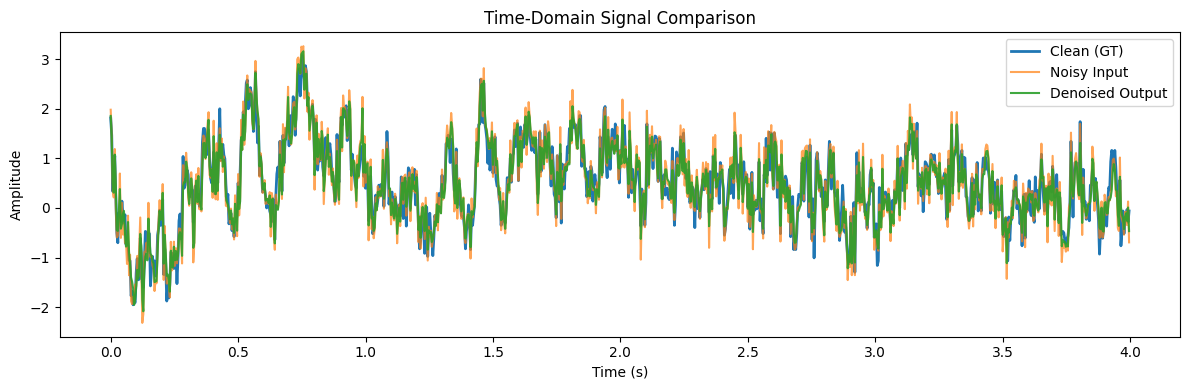

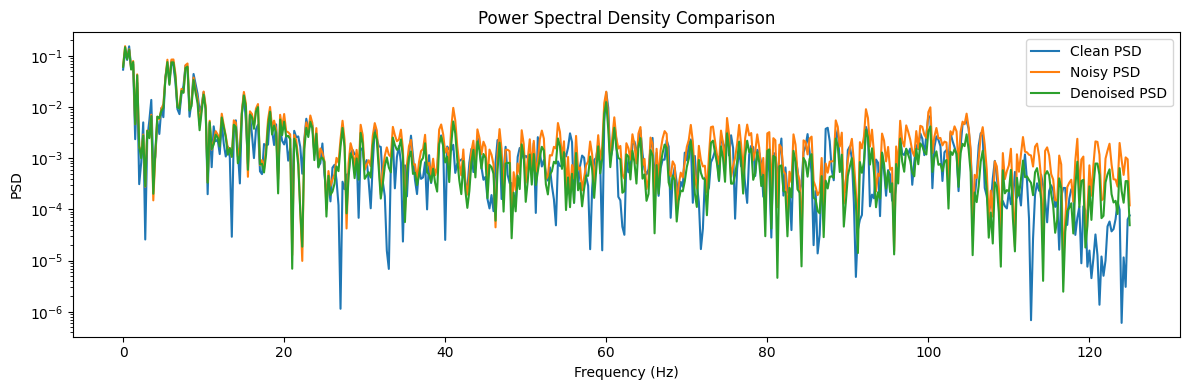

In [15]:
# Get a sample from the test_loader (e.g., the first sample)
for artifact_input, clean_input in test_loader:
    artifact_input, clean_input = artifact_input.to(device), clean_input.to(device)
    with torch.no_grad():
        predicted_residual = G(artifact_input)
        denoised_tensor = artifact_input - predicted_residual
    # Extract the first sample in the batch (assume shape [batch, 1, SEG_LEN])
    sample_clean_signal   = clean_input.cpu().numpy()[0, 0]
    sample_artifact_signal = artifact_input.cpu().numpy()[0, 0]
    denoised_signal        = denoised_tensor.cpu().numpy()[0, 0]
    break  # exit the loop after one sample is obtained

# Use these samples for plotting
fs = 250.0  # Sampling frequency (Hz)
times = np.arange(SEG_LEN) / fs

# Time-domain plot
plt.figure(figsize=(12, 4))
plt.plot(times, sample_clean_signal, label="Clean (GT)", linewidth=2)
plt.plot(times, sample_artifact_signal, label="Noisy Input", alpha=0.7)
plt.plot(times, denoised_signal, label="Denoised Output", alpha=0.9)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time-Domain Signal Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# PSD comparison using Welch's method
f_clean, P_clean = welch(sample_clean_signal, fs=fs, nperseg=SEG_LEN)
f_artifact, P_artifact = welch(sample_artifact_signal, fs=fs, nperseg=SEG_LEN)
f_denoised, P_denoised = welch(denoised_signal, fs=fs, nperseg=SEG_LEN)

plt.figure(figsize=(12, 4))
plt.semilogy(f_clean, P_clean, label="Clean PSD")
plt.semilogy(f_artifact, P_artifact, label="Noisy PSD")
plt.semilogy(f_denoised, P_denoised, label="Denoised PSD")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Power Spectral Density Comparison")
plt.legend()
plt.tight_layout()
plt.show()